# Phase 3: Dirt Regeneration Patterns

## Motivation

In Phases 1 and 2, the robot cleaned a **static** environment: tiles started dirty and, once cleaned, stayed clean forever. This is unrealistic — in a real apartment, rooms get dirty again at different rates. The kitchen gets messy during meal prep, the living room accumulates dust from foot traffic, while the storage closet rarely needs attention.

In this phase, we introduce **periodic dirt bursts**: each room regenerates dirt at a rate proportional to its real-world usage. The critical challenge is that the agent must learn, purely from reward signals, that certain rooms yield more cleaning rewards and should be visited more often.

### Research Questions

1. Can an RL agent learn to **prioritize high-traffic rooms** (kitchen > living room > bedroom > storage) without observing the dirt grid?
2. Does the agent's **room visit frequency** converge toward the **dirt production rate** of each room?
3. How does an agent trained in a static environment perform when deployed in a dirt-regeneration environment (transfer gap)?

### Experimental Design

- **Environment**: 15×15 apartment (same as Phase 2) with charger at hallway center (7,7)
- **Dirt mechanic**: Periodic bursts — every N steps per room, a fraction of clean tiles re-dirty

## Setup

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt


sys.path.insert(0, '.')

from config import (
    PHASE2_HALLWAY_CONFIG, DIRT_PATTERN_CONFIG,
    DIRT_BURST_CONFIG, ROOM_DEFINITIONS,
    DIRT_PATTERN_EPISODES, DIRT_PATTERN_MAX_STEPS,
    SEEDS, REWARDS, BATTERY_BINS,
)
from environment import CleaningRobotEnv, DirtRegenerationEnv
from agents import QLearningAgent, SARSAAgent
from utils import (
    create_agent, run_dirt_experiment, evaluate_dirt_agent,
    plot_learning_curves, plot_multi_metric, plot_battery_analysis,
    plot_coverage_heatmap, plot_apartment_layout, summary_table,
    plot_room_visit_comparison, plot_dirt_timeline, plot_cleans_over_training,
    plot_room_visit_evolution, dirt_summary_table,
    compute_expected_dirt_ratios, compute_room_visit_ratios,
    run_experiment, evaluate_agent, train_agent_dirt,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

print(f"Dirt pattern episodes: {DIRT_PATTERN_EPISODES}")
print(f"Max steps per episode: {DIRT_PATTERN_MAX_STEPS}")
print(f"Seeds: {SEEDS}")
print(f"Charger position: {DIRT_PATTERN_CONFIG['charger_pos']}")

Dirt pattern episodes: 15000
Max steps per episode: 800
Seeds: [42, 123, 256, 789, 1024]
Charger position: (7, 7)


## 1. Environment Overview

### 1.1 Apartment Layout

We use the same 15×15 apartment from Phase 2, with the charger at the hallway center (7,7) for symmetric room access.

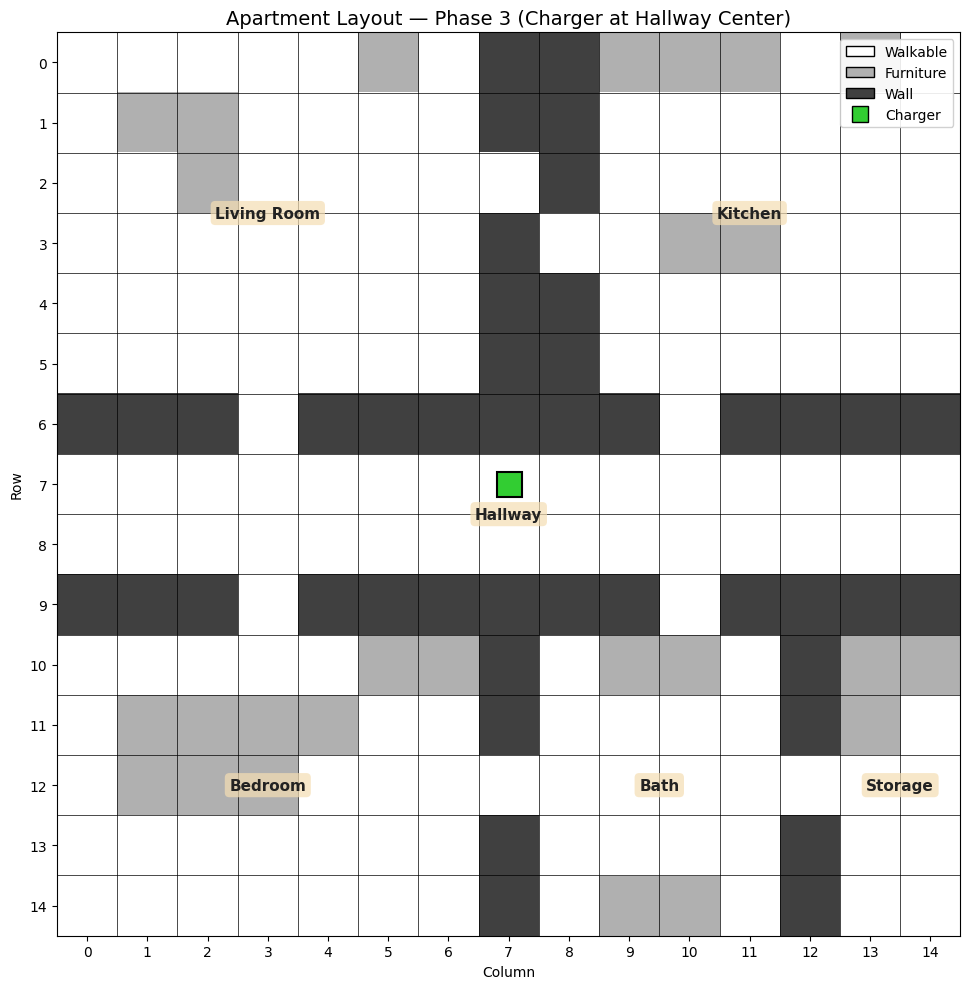

Grid size: 15x15
Walkable tiles: 155
Cleanable tiles: 154
Charger: (7, 7)

Room sizes (walkable tiles):
      Living Room: 38 tiles
          Kitchen: 31 tiles
          Hallway: 29 tiles
          Bedroom: 26 tiles
         Bathroom: 16 tiles
          Storage: 7 tiles


In [2]:
# Visualize the apartment
env_viz = DirtRegenerationEnv(DIRT_PATTERN_CONFIG, max_steps=DIRT_PATTERN_MAX_STEPS)
fig, ax = plot_apartment_layout(env_viz)
ax.set_title("Apartment Layout — Phase 3 (Charger at Hallway Center)", fontsize=14)
plt.show()

print(f"Grid size: {env_viz.rows}x{env_viz.cols}")
print(f"Walkable tiles: {len(env_viz.walkable)}")
print(f"Cleanable tiles: {len(env_viz.cleanable)}")
print(f"Charger: {env_viz.charger_pos}")
print(f"\nRoom sizes (walkable tiles):")
for room, tiles in env_viz.room_tiles.items():
    print(f"  {room.replace('_', ' ').title():>15}: {len(tiles)} tiles")

### 1.2 Dirt Burst Configuration

Each room has three parameters:
- **Burst interval**: how often (in steps) a burst is evaluated
- **Burst probability**: chance the burst fires each interval
- **Burst intensity**: fraction of the room's cleanable tiles that get re-dirtied

The **expected dirt rate** per room is proportional to `probability × intensity / interval`.

Room              Interval     Prob  Intensity    Dirt Rate
------------------------------------------------------------
Kitchen                 15      0.8        0.5        53.5%
Living Room             20      0.7        0.4        28.1%
Bedroom                 40      0.5        0.3         7.5%
Bathroom                40      0.5        0.3         7.5%
Hallway                 50      0.3        0.2         2.4%
Storage                 80      0.2        0.2         1.0%


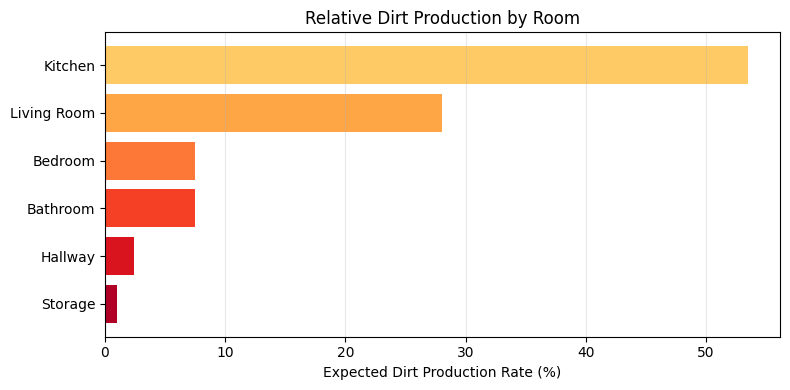

In [3]:
# Display dirt burst configuration
expected_ratios = compute_expected_dirt_ratios(DIRT_BURST_CONFIG)

print(f"{'Room':<15} {'Interval':>10} {'Prob':>8} {'Intensity':>10} {'Dirt Rate':>12}")
print("-" * 60)

# Sort by dirt rate (descending)
sorted_rooms = sorted(expected_ratios.keys(), key=lambda r: expected_ratios[r], reverse=True)
for room in sorted_rooms:
    cfg = DIRT_BURST_CONFIG[room]
    print(f"{room.replace('_', ' ').title():<15} "
          f"{cfg['burst_interval']:>10} "
          f"{cfg['burst_probability']:>8.1f} "
          f"{cfg['burst_intensity']:>10.1f} "
          f"{expected_ratios[room]*100:>11.1f}%")

# Bar chart of expected dirt rates
fig, ax = plt.subplots(figsize=(8, 4))
rooms = [r.replace('_', ' ').title() for r in sorted_rooms]
rates = [expected_ratios[r] * 100 for r in sorted_rooms]
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(rooms)))
ax.barh(rooms[::-1], rates[::-1], color=colors[::-1])
ax.set_xlabel("Expected Dirt Production Rate (%)")
ax.set_title("Relative Dirt Production by Room")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 1.3 Dirt Burst Demo

Let's run a single episode with a random agent to visualize how dirt levels change over time.

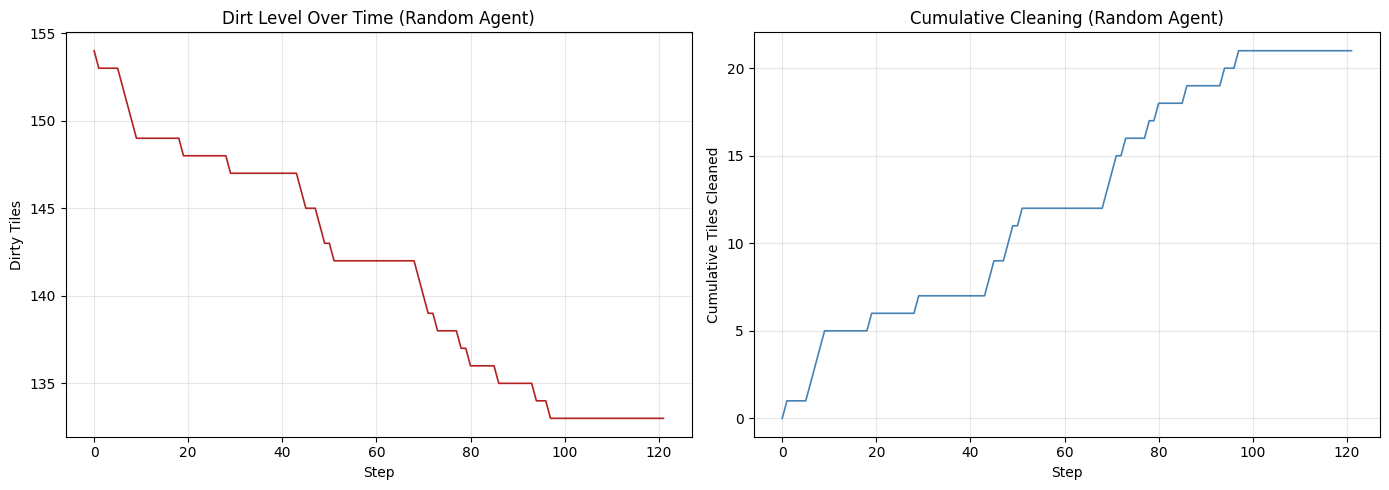

Episode ended at step 121 (event: battery_dead)
Total bursts fired: 0
Total tiles cleaned (including re-cleans): 21
Final dirty tiles: 133


In [4]:
# Demo: run a random agent and track dirt levels
demo_env = DirtRegenerationEnv(DIRT_PATTERN_CONFIG, max_steps=DIRT_PATTERN_MAX_STEPS)
state = demo_env.reset(seed=42)

dirt_levels = [int(demo_env.dirt_grid.sum())]
cleans_cumulative = [0]
total_cleans = 0

for step in range(DIRT_PATTERN_MAX_STEPS):
    if demo_env.done:
        break
    action = np.random.randint(5)  # random agent
    state, reward, done, info = demo_env.step(action)
    dirt_levels.append(info['current_dirt'])
    total_cleans = info['total_cleans']
    cleans_cumulative.append(total_cleans)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dirt level over time
ax = axes[0]
ax.plot(dirt_levels, color='firebrick', linewidth=1.2)
for burst_step, bursts in demo_env.burst_log:
    ax.axvline(burst_step, color='orange', alpha=0.2, linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Dirty Tiles')
ax.set_title('Dirt Level Over Time (Random Agent)')
ax.grid(True, alpha=0.3)

# Cumulative cleans
ax = axes[1]
ax.plot(cleans_cumulative, color='steelblue', linewidth=1.2)
ax.set_xlabel('Step')
ax.set_ylabel('Cumulative Tiles Cleaned')
ax.set_title('Cumulative Cleaning (Random Agent)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Episode ended at step {len(dirt_levels)-1} (event: {info['event']})")
print(f"Total bursts fired: {len(demo_env.burst_log)}")
print(f"Total tiles cleaned (including re-cleans): {total_cleans}")
print(f"Final dirty tiles: {dirt_levels[-1]}")

---

## 2. Experiment 5: Training with Dirt Regeneration

We train SARSA + UCB in the dirt regeneration environment for 15,000 episodes with longer episodes (800 steps max) to give the agent time to patrol and recharge.

**Hypothesis**: The agent should learn to:
1. Patrol rooms cyclically (rather than cleaning once and stopping)
2. Visit high-dirt rooms (kitchen, living room) more frequently
3. Manage battery to sustain long patrol routes

In [5]:
# Experiment 5: SARSA + UCB trained WITH dirt regeneration
print("Training SARSA + UCB with dirt regeneration...")
print(f"  Episodes: {DIRT_PATTERN_EPISODES}, Max steps: {DIRT_PATTERN_MAX_STEPS}")
print(f"  Seeds: {SEEDS}")
print()

dirt_metrics, dirt_agents = run_dirt_experiment(
    algorithm="sarsa",
    exploration="ucb",
    config=DIRT_PATTERN_CONFIG,
    num_episodes=DIRT_PATTERN_EPISODES,
    max_steps=DIRT_PATTERN_MAX_STEPS,
    seeds=SEEDS,
)

print("Training complete!")

Training SARSA + UCB with dirt regeneration...
  Episodes: 15000, Max steps: 800
  Seeds: [42, 123, 256, 789, 1024]

Training complete!


### 2.1 Learning Curves

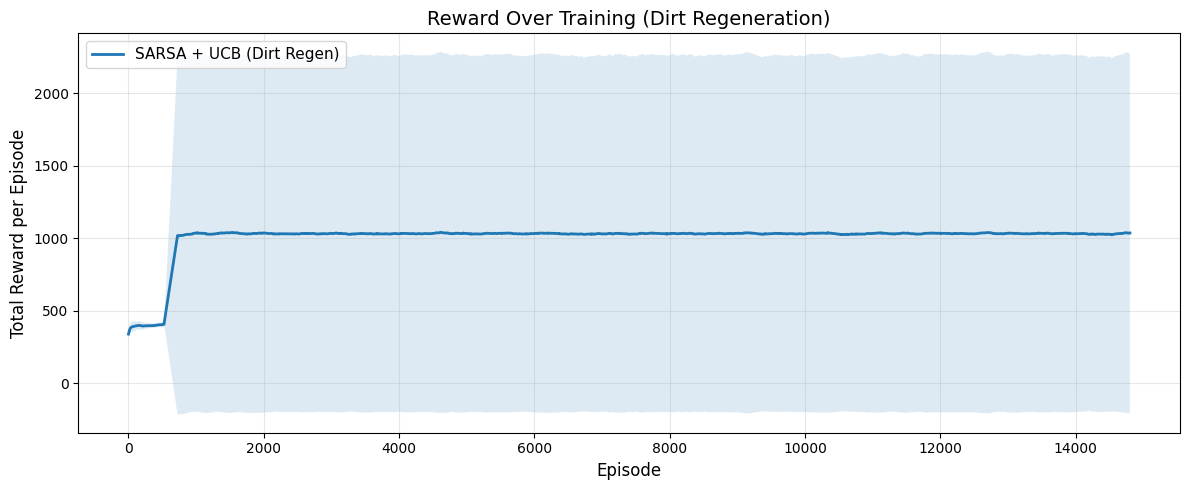

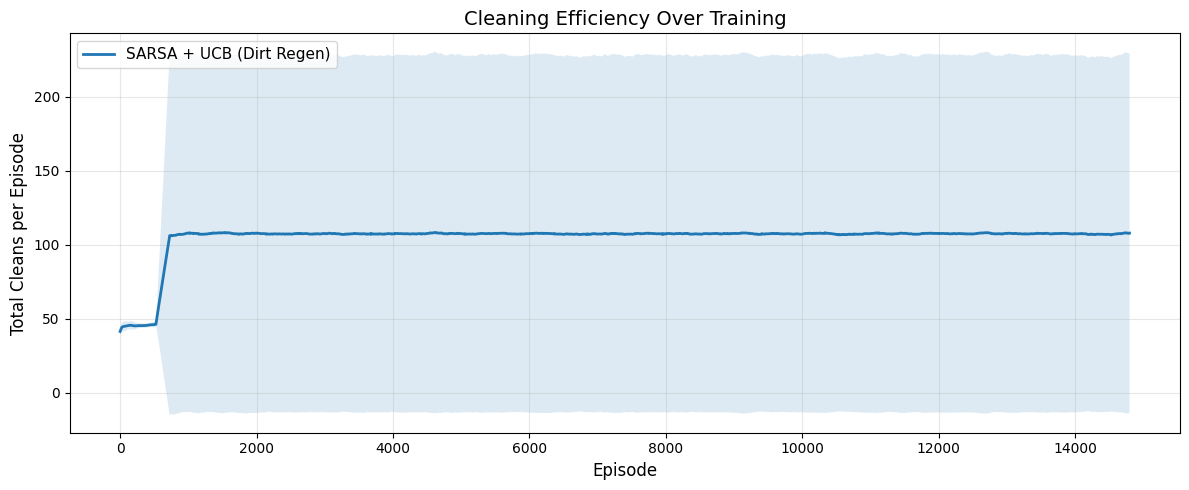

In [6]:
# Learning curves: reward and total cleans
results_dirt = {"SARSA + UCB (Dirt Regen)": dirt_metrics}

fig, ax = plot_learning_curves(
    results_dirt, metric="rewards", window=200,
    title="Reward Over Training (Dirt Regeneration)",
    ylabel="Total Reward per Episode",
)
plt.show()

fig, ax = plot_cleans_over_training(results_dirt, window=200)
plt.show()

### 2.2 Multi-Metric Dashboard

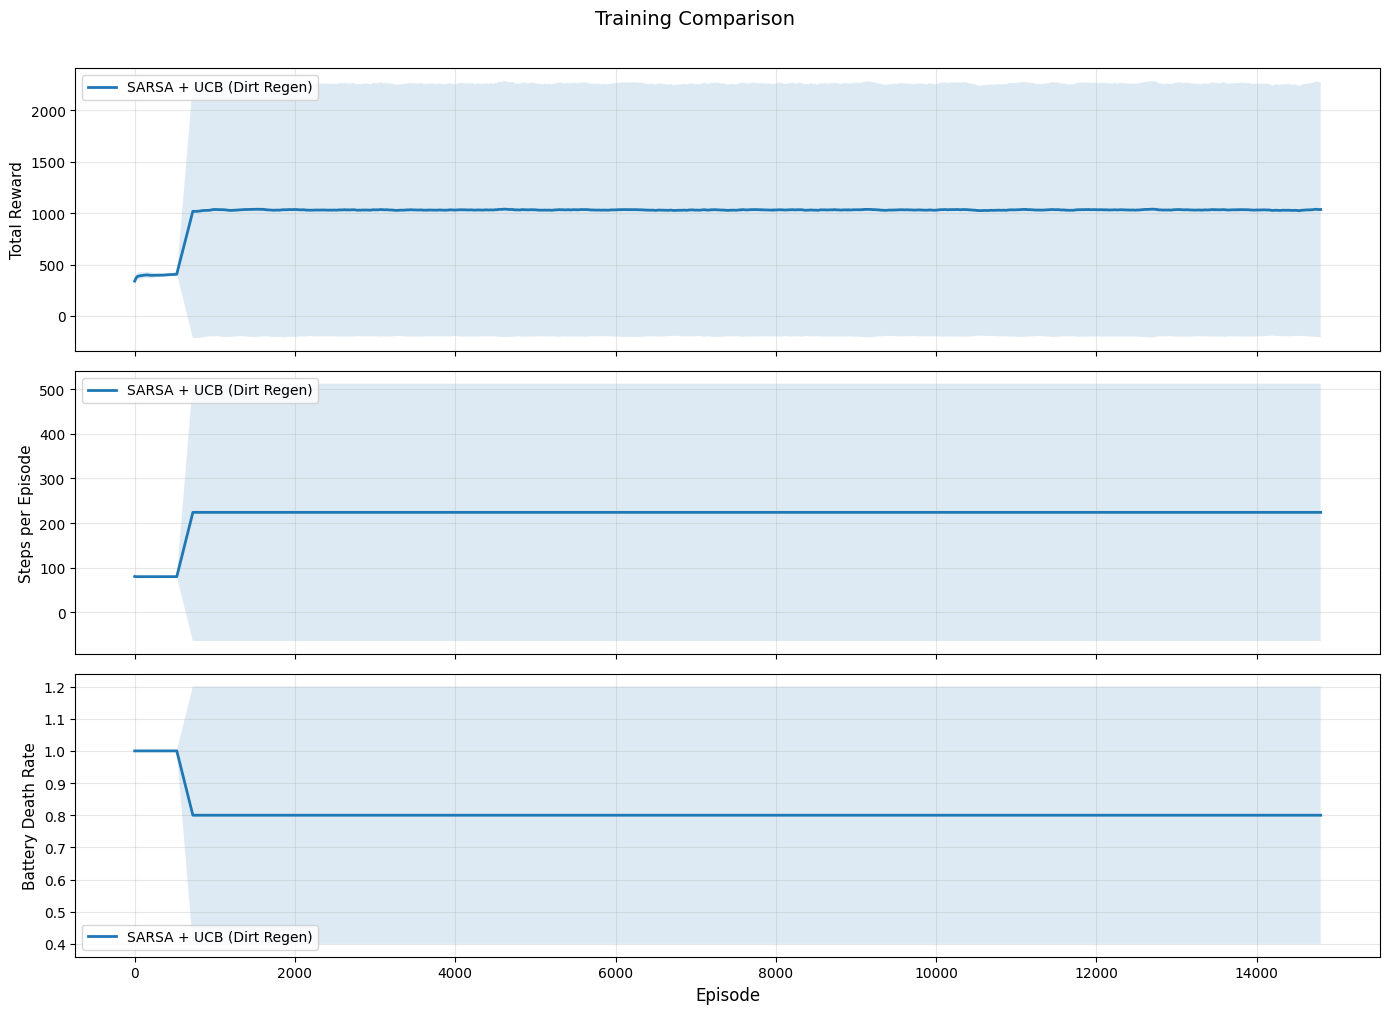

In [7]:
fig, axes = plot_multi_metric(
    results_dirt,
    metrics=["rewards", "steps", "deaths"],
    window=200,
    figsize=(14, 10),
)
plt.show()

### 2.3 Battery Management

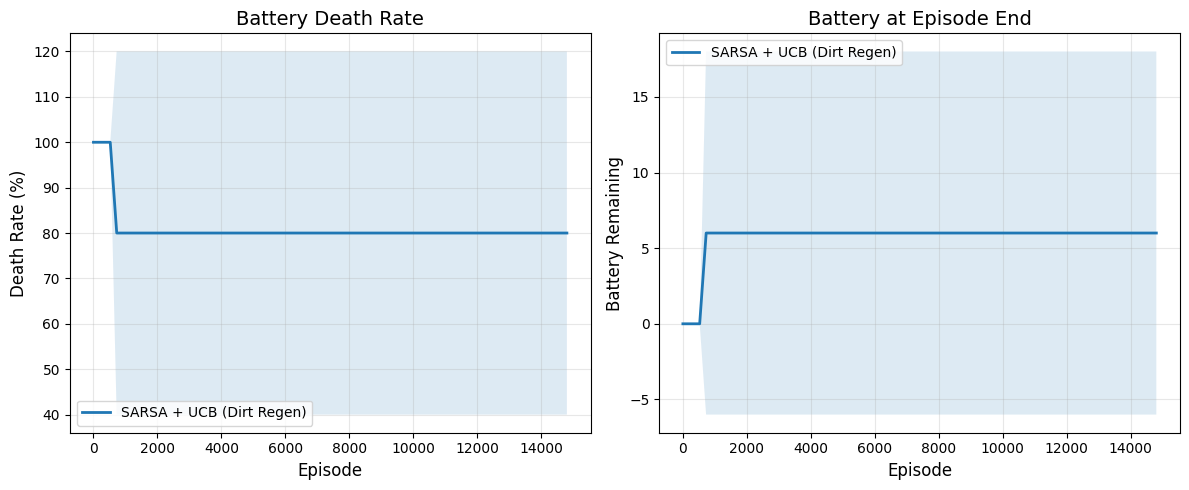

In [8]:
fig, axes = plot_battery_analysis(results_dirt, window=200)
plt.show()

### 2.4 Room Visit Proportions Over Training

This is the key plot: do the agent's room visit ratios converge toward the dirt production rates (shown as dashed lines)?

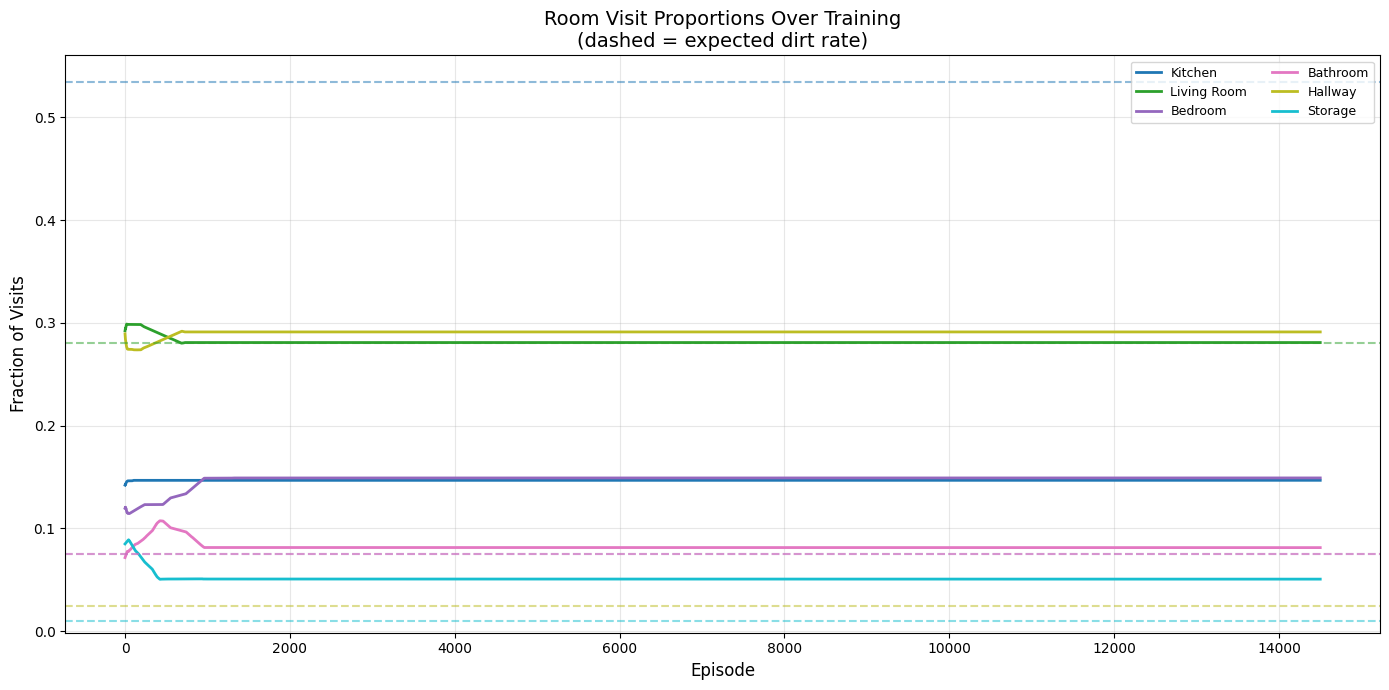

In [9]:
fig, ax = plot_room_visit_evolution(
    dirt_metrics,
    window=500,
    figsize=(14, 7),
)
plt.show()

---

## 3. Experiment 6: Static Agent Baseline (Transfer Gap)

As a control, we take an agent trained on the **static** apartment (Phase 2 hallway config — no dirt regeneration) and evaluate it in the dirt regeneration environment. This quantifies the **transfer gap**: how much does an agent lose by not training for the specific dirt pattern?

In [ ]:
print("Training SARSA + UCB on static apartment (baseline)...")
print(f"  Episodes: {DIRT_PATTERN_EPISODES}")
print()

static_metrics, static_agents = run_experiment(
    algorithm="sarsa",
    exploration="ucb",
    config=PHASE2_HALLWAY_CONFIG,
    num_episodes=DIRT_PATTERN_EPISODES,
    seeds=SEEDS,
)

print("Static training complete!")

Training SARSA + UCB on static apartment (baseline)...
  Episodes: 15000

Static training complete!


---

## 4. Greedy Evaluation & Comparison

We evaluate both agents (dirt-trained and static-trained) **in the dirt regeneration environment** using greedy policies (no exploration). This is the fair comparison: same evaluation environment, different training.

In [ ]:

eval_env = DirtRegenerationEnv(DIRT_PATTERN_CONFIG, max_steps=DIRT_PATTERN_MAX_STEPS)

print("Evaluating dirt-trained agent...")
eval_dirt = evaluate_dirt_agent(eval_env, dirt_agents[0], num_episodes=100, seed=42)

print("Evaluating static-trained agent in dirt environment...")
eval_static = evaluate_dirt_agent(eval_env, static_agents[0], num_episodes=100, seed=42)

print("Evaluation complete!")

Evaluating dirt-trained agent...
Evaluating static-trained agent in dirt environment...
Evaluation complete!


### 4.1 Summary Table

In [12]:
eval_comparison = {
    "SARSA+UCB (Dirt-Trained)": eval_dirt,
    "SARSA+UCB (Static-Trained)": eval_static,
}

dirt_summary_table(eval_comparison)

Agent                            Reward   Cleans  Death%   Batt  │ Room Visit Ratios (vs Expected)
                                                                 │      Kitchen   Living Room       Bedroom      Bathroom       Hallway       Storage
-----------------------------------------------------------------------------------------------------------------------------------------------------
Expected (dirt rate)                                             │        53.5%         28.1%          7.5%          7.5%          2.4%          1.0%
-----------------------------------------------------------------------------------------------------------------------------------------------------
SARSA+UCB (Dirt-Trained)         3470.0    346.4    0.0%   30.0  │         0.0%         65.7%          0.0%          0.0%         34.3%          0.0%
SARSA+UCB (Static-Trained)        420.0     47.3  100.0%    0.0  │         0.0%         62.0%          0.0%          0.0%         38.0%          0.0%
-

### 4.2 Room Visit Frequency Comparison

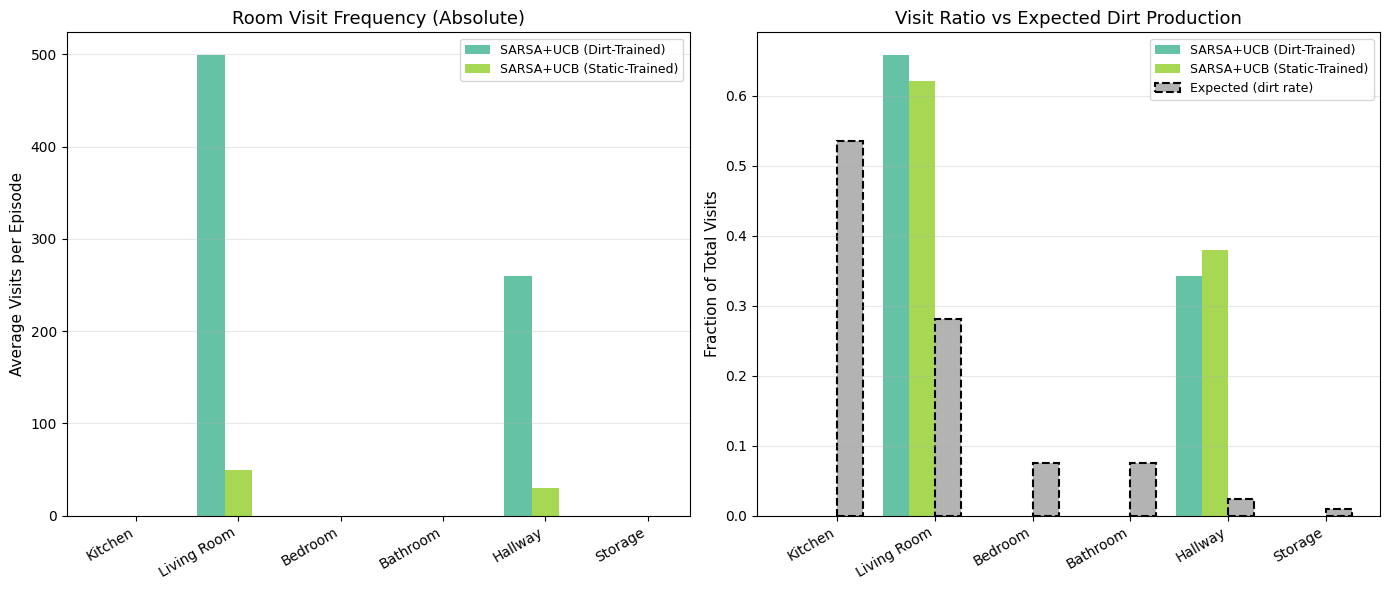

In [13]:
fig, axes = plot_room_visit_comparison(eval_comparison)
plt.show()

### 4.3 Dirt Timeline — Trained Agent vs Static Agent

Side-by-side comparison of how dirt levels evolve during a single evaluation episode.

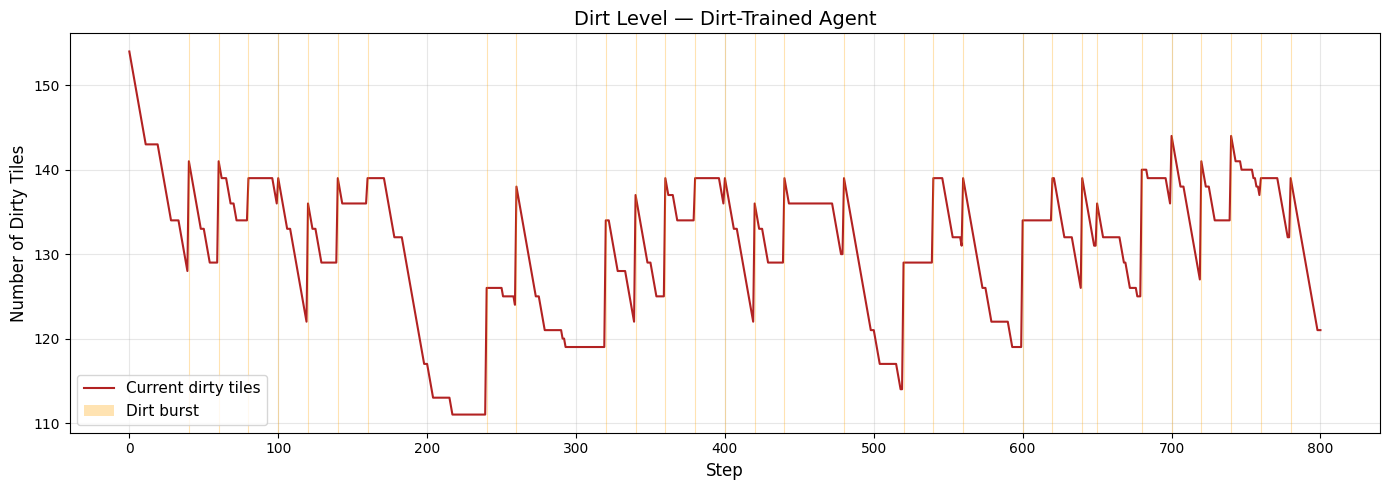

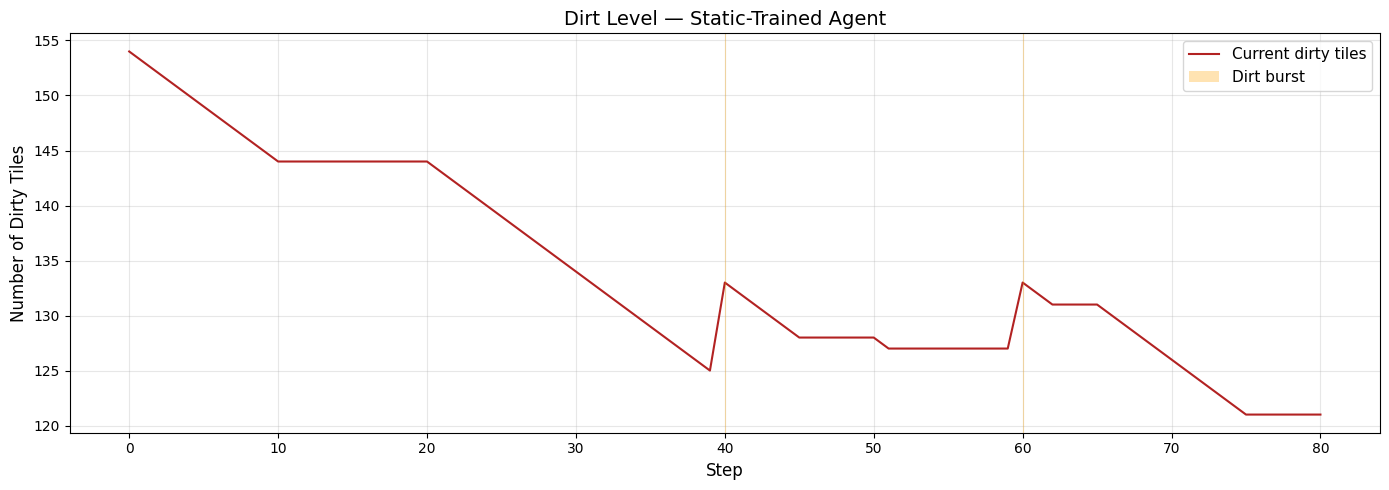

In [14]:
# Dirt timeline for dirt-trained agent
timeline_env = DirtRegenerationEnv(DIRT_PATTERN_CONFIG, max_steps=DIRT_PATTERN_MAX_STEPS)

fig, ax = plot_dirt_timeline(timeline_env, dirt_agents[0], max_steps=DIRT_PATTERN_MAX_STEPS, seed=42)
ax.set_title("Dirt Level — Dirt-Trained Agent", fontsize=14)
plt.show()

fig, ax = plot_dirt_timeline(timeline_env, static_agents[0], max_steps=DIRT_PATTERN_MAX_STEPS, seed=42)
ax.set_title("Dirt Level — Static-Trained Agent", fontsize=14)
plt.show()

### 4.4 Visit Heatmaps

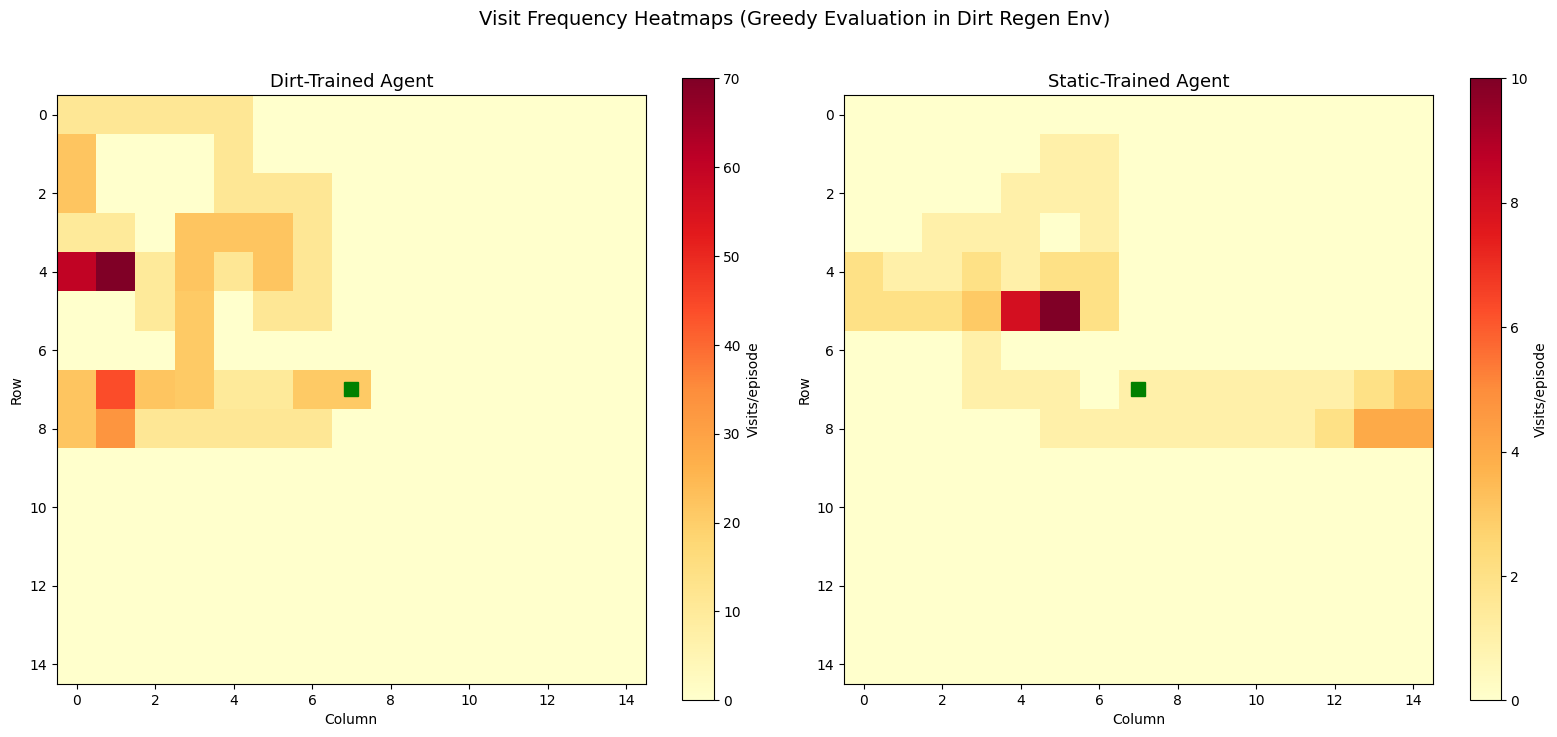

In [15]:
# Side-by-side heatmaps
heatmap_env = DirtRegenerationEnv(DIRT_PATTERN_CONFIG, max_steps=DIRT_PATTERN_MAX_STEPS)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Dirt-trained agent heatmap
visit_counts_dirt = np.zeros((heatmap_env.rows, heatmap_env.cols))
for ep in range(100):
    state = heatmap_env.reset(seed=42 + ep)
    state_idx = heatmap_env.state_to_index(state)
    visit_counts_dirt[state[0], state[1]] += 1
    while not heatmap_env.done:
        action = dirt_agents[0].get_greedy_action(state_idx)
        next_state, reward, done, info = heatmap_env.step(action)
        state_idx = heatmap_env.state_to_index(next_state)
        visit_counts_dirt[next_state[0], next_state[1]] += 1
visit_counts_dirt /= 100

ax = axes[0]
im = ax.imshow(visit_counts_dirt, cmap='YlOrRd', origin='upper')
ax.set_title('Dirt-Trained Agent', fontsize=13)
ax.set_xlabel('Column')
ax.set_ylabel('Row')
plt.colorbar(im, ax=ax, label='Visits/episode')
cr, cc = heatmap_env.charger_pos
ax.plot(cc, cr, 's', color='green', markersize=10)

# Static-trained agent heatmap
visit_counts_static = np.zeros((heatmap_env.rows, heatmap_env.cols))
for ep in range(100):
    state = heatmap_env.reset(seed=42 + ep)
    state_idx = heatmap_env.state_to_index(state)
    visit_counts_static[state[0], state[1]] += 1
    while not heatmap_env.done:
        action = static_agents[0].get_greedy_action(state_idx)
        next_state, reward, done, info = heatmap_env.step(action)
        state_idx = heatmap_env.state_to_index(next_state)
        visit_counts_static[next_state[0], next_state[1]] += 1
visit_counts_static /= 100

ax = axes[1]
im = ax.imshow(visit_counts_static, cmap='YlOrRd', origin='upper')
ax.set_title('Static-Trained Agent', fontsize=13)
ax.set_xlabel('Column')
ax.set_ylabel('Row')
plt.colorbar(im, ax=ax, label='Visits/episode')
ax.plot(cc, cr, 's', color='green', markersize=10)

fig.suptitle('Visit Frequency Heatmaps (Greedy Evaluation in Dirt Regen Env)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Evaluation Bar Charts

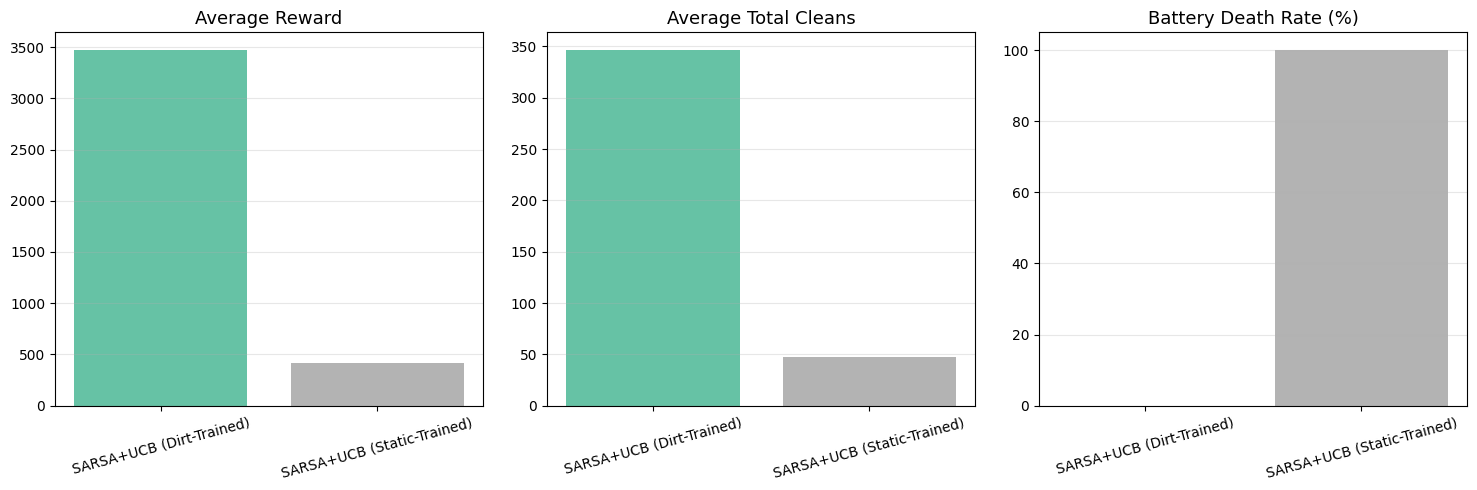

In [16]:
# Standard evaluation bar chart (reward, death rate, total cleans)
labels = list(eval_comparison.keys())
n = len(labels)
colors = plt.cm.Set2(np.linspace(0, 1, n))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Reward
vals = [np.mean(eval_comparison[l]['rewards']) for l in labels]
axes[0].bar(labels, vals, color=colors)
axes[0].set_title('Average Reward', fontsize=13)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

# Total cleans
vals = [np.mean(eval_comparison[l]['total_cleans']) for l in labels]
axes[1].bar(labels, vals, color=colors)
axes[1].set_title('Average Total Cleans', fontsize=13)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

# Death rate
vals = [np.mean(eval_comparison[l]['deaths']) * 100 for l in labels]
axes[2].bar(labels, vals, color=colors)
axes[2].set_title('Battery Death Rate (%)', fontsize=13)
axes[2].set_ylim(0, 105)
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## 5. Analysis & Conclusions

### Key Findings

1. **Training in the regeneration environment transfers**: when evaluated in the dirt-regeneration environment, **SARSA+UCB (dirt-trained)** achieves much higher return and throughput (**3470 reward**, **346 cleans/episode**) with **0% battery deaths**, compared to the **static-trained** agent (**420 reward**, **47 cleans/episode**) which dies **100%** of the time.

2. **Room-prioritization is not achieved**: the visit ratios do **not** match the expected dirt production rates. In particular, the dirt-trained policy concentrates visits in **Living Room (~65.7%)** and **Hallway (~34.3%)**, while **Kitchen/Bedroom/Bathroom/Storage are ~0%**.



Interpretation:
- With partial observability (no dirt-grid observation) and no penalty for leaving dirt uncleaned, the agent can maximize reward by repeatedly cleaning where it is easiest/closest, even if other rooms generate more dirt.

### Limitations

- The agent cannot observe the dirt grid, so it cannot react to bursts online; it can only learn a patrol distribution.
- Without a global penalty for dirt accumulation, the objective is closer to “collect +10 events” than “keep the whole apartment clean.”


